In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
python_res = pd.read_csv("./python_res100M.csv")
rust_res = pd.read_csv("./rust_res100M.csv")

In [3]:
python_res

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall
0,100M,lmi,668.991919,297.614494,0.078106,4836.345477,10.095815,t3-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.472740
1,100M,lmi,0.000000,0.000000,0.000000,3644.450240,600.482427,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.950267
2,100M,lmi,0.000000,0.000000,0.000000,3644.450240,669.131979,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.957593
3,100M,lmi,0.000000,0.000000,0.000000,3644.450240,342.691670,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.912973
4,100M,lmi,0.000000,0.000000,0.000000,3644.450240,463.654665,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.941483
...,...,...,...,...,...,...,...,...,...
74,100M,lmi,431.958028,381.125796,0.092516,6885.664245,2329.974032,t2-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.525063
75,100M,lmi,408.407388,344.681899,0.066910,6744.211916,2703.481891,t2-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.802277
76,100M,lmi,408.407388,344.681899,0.066910,6744.211916,2704.211206,t2-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.798653
77,100M,lmi,431.958028,381.125796,0.092516,6885.664245,2315.322739,t2-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.744757


In [4]:
python_res = python_res[python_res["params"].str.startswith("t1-")]

rust_res = rust_res[rust_res["params"].str.contains("task1")]

python_res = python_res[python_res["size"] == "100M"]
rust_res = rust_res[rust_res["size"] == "100M"]

python_res['nprobe'] = python_res['params'].str.extract('nprobe=(\d+)').astype(int)
rust_res['nprobe'] = rust_res['params'].str.extract('nprobe=(\d+)').astype(int)

python_res = python_res.reset_index(drop=True)
rust_res = rust_res.reset_index(drop=True)

max_python_nprobe = python_res["nprobe"].max()
max_rust_nprobe = rust_res["nprobe"].max()
max_nprobe = max(max_python_nprobe, max_rust_nprobe)

python_res = python_res[python_res["nprobe"] <= max_nprobe]
rust_res = rust_res[rust_res["nprobe"] <= max_nprobe]

In [5]:
print(len(python_res))
python_res.head()

30


,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,100M,lmi,0.0,0.0,0.0,3644.45024,600.482427,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.950267,22
1,100M,lmi,0.0,0.0,0.0,3644.45024,669.131979,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.957593,27
2,100M,lmi,0.0,0.0,0.0,3644.45024,342.691670,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.912973,11
3,100M,lmi,0.0,0.0,0.0,3644.45024,463.654665,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.941483,18
4,100M,lmi,0.0,0.0,0.0,3644.45024,733.117499,t1-100M-epochs=15-lr=0.00098-sample=1000000-al...,0.960163,29


In [6]:
print(len(rust_res))
rust_res.head()

30


,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,100M,rust-lmi-task1,0.0,0.0,0.0,5148.704095,221.905699,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.961763,16
1,100M,rust-lmi-task1,0.0,0.0,0.0,5148.704095,182.801270,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.954007,13
2,100M,rust-lmi-task1,0.0,0.0,0.0,5148.704095,19.701376,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.604517,1
3,100M,rust-lmi-task1,0.0,0.0,0.0,5148.704095,254.260086,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.967450,19
4,100M,rust-lmi-task1,0.0,0.0,0.0,5148.704095,171.410593,rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...,0.950183,12


Text(0, 0.5, 'buildtime')

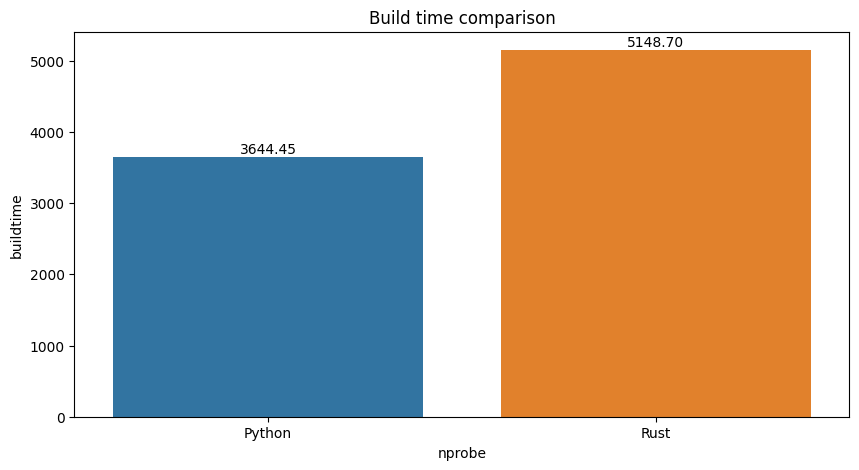

In [18]:
plt.figure(figsize=(10, 5))

plt.title("Build time comparison")

python_avg_buildtime = python_res['buildtime'].mean()
rust_avg_buildtime = rust_res['buildtime'].mean()

build_time_data = pd.DataFrame({
    'Implementation': ['Python', 'Rust'],
    'Build Time (s)': [python_avg_buildtime, rust_avg_buildtime]
})

sns.barplot(x='Implementation', y='Build Time (s)', data=build_time_data, hue='Implementation')

for i, v in enumerate(build_time_data['Build Time (s)']):
    plt.text(i, v + 50, f'{v:.2f}', ha='center')


# plt.grid(True)

plt.xlabel('nprobe')
plt.ylabel('buildtime')

Text(0, 0.5, 'recall')

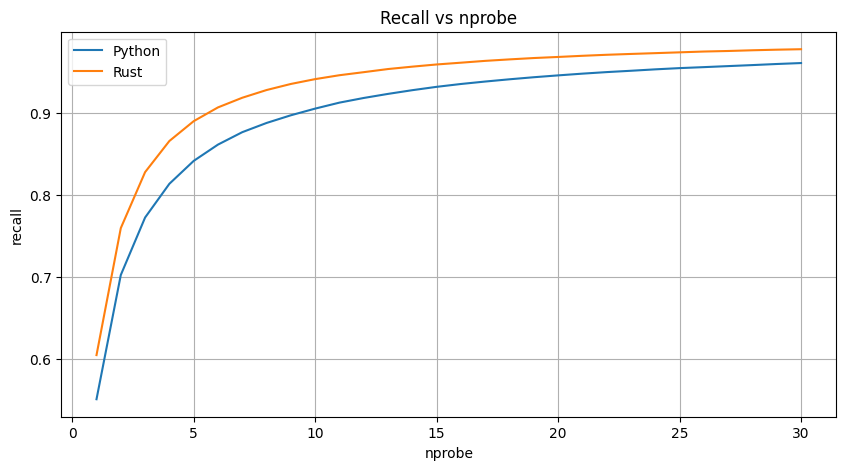

In [7]:
plt.figure(figsize=(10, 5))

plt.title("Recall vs nprobe")

sns.lineplot(x='nprobe', y='recall', data=python_res, label='Python')
sns.lineplot(x='nprobe', y='recall', data=rust_res, label='Rust')

plt.grid(True)

plt.xlabel('nprobe')
plt.ylabel('recall')

In [53]:
# Print rows for nprobe 1
print(python_res[python_res["nprobe"] == 1])
print(rust_res[rust_res["nprobe"] == 1])


    size algo  modelingtime  encdatabasetime  encqueriestime   buildtime  \
23  100M  lmi           0.0              0.0             0.0  3644.45024   

    querytime                                             params    recall  \
23  11.064855  t1-100M-epochs=15-lr=0.00098-sample=1000000-al...  0.550607   

    nprobe  
23       1  
   size            algo  modelingtime  encdatabasetime  encqueriestime  \
2  100M  rust-lmi-task1           0.0              0.0             0.0   

     buildtime  querytime                                             params  \
2  5148.704095  19.701376  rust-lmi-task1-ds=100M-ep=15-lr=0.00098-sample...   

     recall  nprobe  
2  0.604517       1  


Text(0, 0.5, 'querytime')

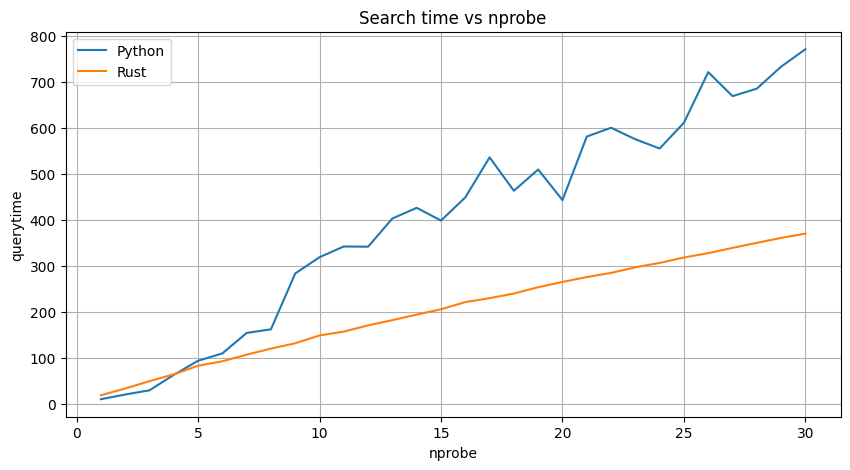

In [55]:
plt.figure(figsize=(10, 5))

plt.title("Search time vs nprobe")

sns.lineplot(x='nprobe', y='querytime', data=python_res, label='Python')
sns.lineplot(x='nprobe', y='querytime', data=rust_res, label='Rust')

plt.grid(True)

plt.xlabel('nprobe')
plt.ylabel('querytime')
